# Bài toán 4: Dự đoán Thời gian Chuyến xe (Trip Duration)

## Mục đích
- Dự đoán thời gian chuyến xe (trip_duration) dựa trên các đặc trưng
- Sử dụng output từ các bài toán trước: `cluster_id`, `rush_hour`
- So sánh nhiều mô hình ML Regressor và chọn mô hình tốt nhất

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
)
from xgboost import XGBRegressor

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load dữ liệu và tái tạo các features từ bài toán trước

In [2]:
# Load processed data
df = pd.read_csv('../data/raw/yellow_tripdata_2016-03_processed.csv')

print(f"✅ Dữ liệu loaded: {df.shape}")
print(f"Các cột trong dataset: {df.columns.tolist()}")
print(f"\nTrip duration stats:")
print(df['trip_duration'].describe())

✅ Dữ liệu loaded: (11411918, 30)
Các cột trong dataset: ['Unnamed: 0', 'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'trip_duration', 'speed', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'time_of_day', 'is_peak_hour', 'is_credit_card', 'total_income', 'location_cluster']

Trip duration stats:
count    1.141192e+07
mean     7.471010e+02
std      4.733584e+02
min      6.100000e+01
25%      3.900000e+02
50%      6.350000e+02
75%      9.950000e+02
max      2.655000e+03
Name: trip_duration, dtype: float64


## 3. Tái tạo cluster_id (từ bài toán 2)

In [3]:
# Sử dụng output từ bài toán cluster
print("Sử dụng cluster_id từ output của bài toán cluster...")

# File yellow_tripdata_2016-03_processed.csv đã được tạo từ cluster.ipynb
# và chứa cột location_cluster
if 'location_cluster' in df.columns:
    df['cluster_id'] = df['location_cluster'].copy()
    df = df.drop('location_cluster', axis=1)
    print(f"✅ Sử dụng location_cluster từ output bài toán cluster")
elif 'cluster_id' not in df.columns:
    raise ValueError('Không tìm thấy cột cluster_id hoặc location_cluster trong dữ liệu.')

print(f"✅ Cluster_id loaded")
print(f"Cluster distribution:\n{df['cluster_id'].value_counts().sort_index()}")


Sử dụng cluster_id từ output của bài toán cluster...
✅ Sử dụng location_cluster từ output bài toán cluster
✅ Cluster_id loaded
Cluster distribution:
cluster_id
-1      454574
 0    10668458
 1      238536
 2       27468
 3       10107
 4       12775
Name: count, dtype: int64


## 4. Sử dụng output của rush_hour (từ bài toán 3)

In [4]:
# Sử dụng output rush_hour từ rush_hour.ipynb (không tái tạo theo rule thời gian)
rush_hour_path = '../data/raw/taxi_cleaned_with_rush_hour.csv'

# Chỉ đọc các cột cần để merge
candidate_cols = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'trip_distance',
    'passenger_count',
    'rush_hour'
]

df_rush = pd.read_csv(rush_hour_path, low_memory=False)
available_cols = [c for c in candidate_cols if c in df_rush.columns]
df_rush = df_rush[available_cols].copy()

# Đồng bộ kiểu datetime để join ổn định
for col in ['tpep_pickup_datetime', 'tpep_dropoff_datetime']:
    if col in df.columns and col in df_rush.columns:
        df[col] = pd.to_datetime(df[col])
        df_rush[col] = pd.to_datetime(df_rush[col])

# Merge theo các khóa chung giữa 2 dataset
merge_keys_preferred = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'trip_distance',
    'passenger_count'
]
merge_keys = [k for k in merge_keys_preferred if k in df.columns and k in df_rush.columns]

if not merge_keys:
    raise ValueError('Không tìm thấy khóa chung để merge rush_hour từ rush_hour.ipynb')

if 'rush_hour' not in df_rush.columns:
    raise ValueError('File output từ rush_hour.ipynb không có cột rush_hour')

before_rows = len(df)
df = df.merge(
    df_rush[merge_keys + ['rush_hour']].drop_duplicates(),
    on=merge_keys,
    how='left'
)

matched_ratio = 1 - df['rush_hour'].isna().mean()
print(f'✅ Đã lấy rush_hour từ {rush_hour_path}')
print(f'Merge keys: {merge_keys}')
print(f'Tỷ lệ match rush_hour: {matched_ratio:.2%}')

# Giữ các dòng có rush_hour hợp lệ từ output trước đó
df = df.dropna(subset=['rush_hour']).copy()
df['rush_hour'] = df['rush_hour'].astype(int)

print(f'Số dòng trước merge: {before_rows:,}')
print(f'Số dòng sau khi giữ rush_hour hợp lệ: {len(df):,}')
print(f'Rush hour distribution:\n{df["rush_hour"].value_counts()}')
print(f'Rush hour ratio: {df["rush_hour"].mean():.2%}')

✅ Đã lấy rush_hour từ ../data/raw/taxi_cleaned_with_rush_hour.csv
Merge keys: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'passenger_count']
Tỷ lệ match rush_hour: 1.75%
Số dòng trước merge: 11,411,918
Số dòng sau khi giữ rush_hour hợp lệ: 199,925
Rush hour distribution:
rush_hour
0    143359
1     56566
Name: count, dtype: int64
Rush hour ratio: 28.29%


## 5. Chuẩn bị Features cho Regressor

In [5]:
# Chọn features để dự đoán trip_duration
# Bao gồm: vị trí, khoảng cách, cluster_id, rush_hour, loại hành khách
feature_cols = [
    'trip_distance',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'cluster_id',
    'rush_hour',
    'passenger_count'
]

# Kiểm tra features có sẵn
available_features = [f for f in feature_cols if f in df.columns]
print(f"Features sử dụng ({len(available_features)}): {available_features}")

X = df[available_features].copy()
y = df['trip_duration'].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature stats:")
print(X.describe())

Features sử dụng (8): ['trip_distance', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'cluster_id', 'rush_hour', 'passenger_count']

X shape: (199925, 8)
y shape: (199925,)

Feature stats:
       trip_distance  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  199925.000000     199925.000000    199925.000000      199925.000000   
mean        2.420576        -73.977416        40.753071         -73.975225   
std         2.243308          0.027054         0.024262           0.027447   
min         0.110000        -74.105347        40.579060         -74.105347   
25%         1.000000        -73.992004        40.738670         -73.991386   
50%         1.660000        -73.982063        40.754829         -73.980026   
75%         2.900000        -73.968552        40.768711         -73.964088   
max        13.260000        -73.715591        40.910316         -73.701294   

       dropoff_latitude     cluster_id      rush_hour  passenger_count  
c

## 6. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTarget distribution:")
print(f"Train - Mean: {y_train.mean():.2f}s, Std: {y_train.std():.2f}s")
print(f"Test  - Mean: {y_test.mean():.2f}s, Std: {y_test.std():.2f}s")

Training set: (159940, 8)
Test set: (39985, 8)

Target distribution:
Train - Mean: 743.52s, Std: 470.26s
Test  - Mean: 745.04s, Std: 468.23s


## 7. Định nghĩa các mô hình Regressor

In [7]:
# Định nghĩa các mô hình với thông tin về scaling requirement
models = {
    'Linear Regression': (LinearRegression(), False),
    'Ridge Regression': (Ridge(alpha=1.0, random_state=42), False),
    'Lasso Regression': (Lasso(alpha=0.1, random_state=42), False),
    'KNN Regressor': (KNeighborsRegressor(n_neighbors=5, n_jobs=-1), True),
    'SVM Regressor': (SVR(kernel='rbf', C=100), True),
    'Random Forest': (RandomForestRegressor(n_estimators=100, max_depth=15, 
                                             random_state=42, n_jobs=-1), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                      learning_rate=0.1, random_state=42), False),
    'XGBoost': (XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                             random_state=42, verbosity=0), False)
}

print(f"✅ {len(models)} mô hình đã được định nghĩa")
for name in models.keys():
    print(f"  - {name}")

✅ 8 mô hình đã được định nghĩa
  - Linear Regression
  - Ridge Regression
  - Lasso Regression
  - KNN Regressor
  - SVM Regressor
  - Random Forest
  - Gradient Boosting
  - XGBoost


## 8. Chuẩn bị Scaler (cho các mô hình yêu cầu scaling)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Dữ liệu đã được scaled")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

✅ Dữ liệu đã được scaled
X_train_scaled shape: (159940, 8)
X_test_scaled shape: (39985, 8)


## 9. Training và Evaluation Models

In [9]:
results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("="*80)
print("TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH")
print("="*80)

for name, (model, needs_scaling) in models.items():
    print(f"\n📊 Training {name}...", end=' ', flush=True)
    
    # Chọn dữ liệu scaled hay không
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled if needs_scaling else X_test
    
    # Train model
    model.fit(X_tr, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    
    # Metrics on test set
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, 
                                  scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    results[name] = {
        'model': model,
        'scaled': needs_scaling,
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2,
        'test_mape': mape,
        'cv_rmse': cv_rmse,
        'cv_rmse_std': np.sqrt(cv_scores.std()),
        'y_pred': y_pred_test
    }
    
    print(f"✅")
    print(f"  RMSE: {rmse:.2f}s | MAE: {mae:.2f}s | R²: {r2:.4f} | MAPE: {mape:.2%}")
    print(f"  CV RMSE: {cv_rmse:.2f}s (±{np.sqrt(cv_scores.std()):.2f}s)")

print("\n" + "="*80)
print("✅ Tất cả mô hình đã được huấn luyện!")
print("="*80)

TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH

📊 Training Linear Regression... ✅
  RMSE: 293.01s | MAE: 217.77s | R²: 0.6084 | MAPE: 41.52%
  CV RMSE: 293.98s (±30.99s)

📊 Training Ridge Regression... ✅
  RMSE: 293.00s | MAE: 217.78s | R²: 0.6084 | MAPE: 41.52%
  CV RMSE: 293.98s (±31.02s)

📊 Training Lasso Regression... ✅
  RMSE: 293.06s | MAE: 217.94s | R²: 0.6082 | MAPE: 41.61%
  CV RMSE: 294.14s (±31.44s)

📊 Training KNN Regressor... ✅
  RMSE: 253.73s | MAE: 180.88s | R²: 0.7064 | MAPE: 28.65%
  CV RMSE: 255.12s (±26.37s)

📊 Training SVM Regressor... ✅
  RMSE: 246.06s | MAE: 171.97s | R²: 0.7238 | MAPE: 25.69%
  CV RMSE: 247.00s (±30.56s)

📊 Training Random Forest... ✅
  RMSE: 238.38s | MAE: 171.40s | R²: 0.7408 | MAPE: 27.36%
  CV RMSE: 238.76s (±30.84s)

📊 Training Gradient Boosting... ✅
  RMSE: 240.89s | MAE: 174.19s | R²: 0.7353 | MAPE: 28.08%
  CV RMSE: 242.11s (±30.73s)

📊 Training XGBoost... ✅
  RMSE: 237.43s | MAE: 171.27s | R²: 0.7429 | MAPE: 27.48%
  CV RMSE: 238.57s (±30.50s)

✅ Tất 

## 10. So sánh kết quả và chọn mô hình tốt nhất

In [10]:
# Tạo dataframe để so sánh các mô hình
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train RMSE': [results[m]['train_rmse'] for m in results.keys()],
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()],
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Test MAPE': [results[m]['test_mape'] for m in results.keys()],
    'CV RMSE': [results[m]['cv_rmse'] for m in results.keys()],
})

# Sắp xếp theo Test RMSE
comparison_df = comparison_df.sort_values('Test RMSE').reset_index(drop=True)

print("\n📊 BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH")
print("="*120)
print(comparison_df.to_string(index=False))
print("="*120)

# Chọn mô hình tốt nhất (theo Test RMSE)
best_model_name = comparison_df.iloc[0]['Model']
best_test_rmse = comparison_df.iloc[0]['Test RMSE']
best_test_r2 = comparison_df.iloc[0]['Test R²']

print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"  Test RMSE: {best_test_rmse:.2f}s")
print(f"  Test R²: {best_test_r2:.4f}")


📊 BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH
            Model  Train RMSE  Test RMSE   Test MAE  Test R²  Test MAPE    CV RMSE
          XGBoost  232.571377 237.427954 171.270219 0.742873   0.274786 238.571783
    Random Forest  194.353597 238.377220 171.402972 0.740813   0.273625 238.758029
Gradient Boosting  237.982208 240.885484 174.185242 0.735330   0.280798 242.109231
    SVM Regressor  245.122331 246.061097 171.970391 0.723834   0.256902 247.001038
    KNN Regressor  206.904276 253.729958 180.878259 0.706352   0.286479 255.121618
 Ridge Regression  293.960463 293.001360 217.779154 0.608418   0.415244 293.976842
Linear Regression  293.959565 293.006284 217.774245 0.608404   0.415174 293.975661
 Lasso Regression  294.126332 293.064666 217.939869 0.608248   0.416054 294.141998

🏆 MÔ HÌNH TỐT NHẤT: XGBoost
  Test RMSE: 237.43s
  Test R²: 0.7429


## 10.1. Chọn 3 Model Tốt Nhất để Tuning

In [11]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Chọn 3 model tốt nhất (có Test RMSE thấp nhất)
top_3_models = comparison_df.head(3)['Model'].tolist()

print(f"🎯 Top 3 mô hình được chọn để tuning:")
for i, model_name in enumerate(top_3_models, 1):
    rmse = comparison_df[comparison_df['Model'] == model_name]['Test RMSE'].values[0]
    r2 = comparison_df[comparison_df['Model'] == model_name]['Test R²'].values[0]
    print(f"   {i}. {model_name}: RMSE={rmse:.2f}s, R²={r2:.4f}")


🎯 Top 3 mô hình được chọn để tuning:
   1. XGBoost: RMSE=237.43s, R²=0.7429
   2. Random Forest: RMSE=238.38s, R²=0.7408
   3. Gradient Boosting: RMSE=240.89s, R²=0.7353


## 10.2. Hyperparameter Tuning cho 3 Model Tốt Nhất

In [12]:
print("="*80)
print("HYPERPARAMETER TUNING CHO 3 MODEL TỐT NHẤT")
print("="*80)

tuned_models = {}

# Định nghĩa tham số tuning cho mỗi model
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
}

for model_name in top_3_models:
    if model_name not in param_grids:
        print(f"⚠️ {model_name} không có tham số tuning được định nghĩa")
        continue
    
    print(f"\n🔧 Tuning {model_name}...", flush=True)
    
    # Lấy model base từ results
    base_model = results[model_name]['model']
    needs_scaling = results[model_name]['scaled']
    
    # Chọn dữ liệu scaled hay không
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled if needs_scaling else X_test
    
    # GridSearchCV với 5-fold CV
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[model_name],
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    
    # Fit grid search
    grid_search.fit(X_tr, y_train)
    
    # Best model
    best_model_tuned = grid_search.best_estimator_
    
    # Predictions
    y_pred_train_tuned = best_model_tuned.predict(X_tr)
    y_pred_test_tuned = best_model_tuned.predict(X_te)
    
    # Metrics
    train_rmse_tuned = np.sqrt(mean_squared_error(y_train, y_pred_train_tuned))
    test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_tuned))
    test_mae_tuned = mean_absolute_error(y_test, y_pred_test_tuned)
    test_r2_tuned = r2_score(y_test, y_pred_test_tuned)
    test_mape_tuned = mean_absolute_percentage_error(y_test, y_pred_test_tuned)
    
    tuned_models[model_name] = {
        'model': best_model_tuned,
        'scaled': needs_scaling,
        'best_params': grid_search.best_params_,
        'best_cv_score': np.sqrt(-grid_search.best_score_),
        'train_rmse': train_rmse_tuned,
        'test_rmse': test_rmse_tuned,
        'test_mae': test_mae_tuned,
        'test_r2': test_r2_tuned,
        'test_mape': test_mape_tuned,
        'y_pred': y_pred_test_tuned
    }
    
    print(f"   ✅ Tuning hoàn tất!")
    print(f"   Best params: {grid_search.best_params_}")
    print(f"   CV RMSE: {np.sqrt(-grid_search.best_score_):.2f}s")
    print(f"   Test RMSE: {test_rmse_tuned:.2f}s | MAE: {test_mae_tuned:.2f}s | R²: {test_r2_tuned:.4f}")

print("\n" + "="*80)
print("✅ Tuning hoàn tất cho tất cả 3 model!")
print("="*80)


HYPERPARAMETER TUNING CHO 3 MODEL TỐT NHẤT

🔧 Tuning XGBoost...
   ✅ Tuning hoàn tất!
   Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 150, 'subsample': 0.9}
   CV RMSE: 234.92s
   Test RMSE: 233.78s | MAE: 167.57s | R²: 0.7507

🔧 Tuning Random Forest...
   ✅ Tuning hoàn tất!
   Best params: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 150}
   CV RMSE: 237.48s
   Test RMSE: 236.54s | MAE: 169.95s | R²: 0.7448

🔧 Tuning Gradient Boosting...
   ✅ Tuning hoàn tất!
   Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.8}
   CV RMSE: 236.69s
   Test RMSE: 235.37s | MAE: 169.28s | R²: 0.7473

✅ Tuning hoàn tất cho tất cả 3 model!


## 10.3. So Sánh Kết Quả Trước và Sau Tuning

In [13]:
# Tạo dataframe so sánh trước và sau tuning
comparison_tuning = []

for model_name in top_3_models:
    if model_name not in tuned_models:
        continue
    
    # Kết quả trước tuning
    before = comparison_df[comparison_df['Model'] == model_name].iloc[0]
    
    # Kết quả sau tuning
    after = tuned_models[model_name]
    
    comparison_tuning.append({
        'Model': model_name,
        'Before Tuning RMSE': before['Test RMSE'],
        'After Tuning RMSE': after['test_rmse'],
        'RMSE Improvement (%)': ((before['Test RMSE'] - after['test_rmse']) / before['Test RMSE'] * 100),
        'Before R²': before['Test R²'],
        'After R²': after['test_r2'],
        'R² Improvement': (after['test_r2'] - before['Test R²'])
    })

comparison_tuning_df = pd.DataFrame(comparison_tuning)

print("\n📊 BẢNG SO SÁNH KẾT QUẢ TRƯỚC VÀ SAU TUNING")
print("="*140)
print(comparison_tuning_df.to_string(index=False))
print("="*140)

# Chọn model tốt nhất sau tuning
best_tuned_model_name = comparison_tuning_df.loc[comparison_tuning_df['After Tuning RMSE'].idxmin(), 'Model']
best_tuned_rmse = comparison_tuning_df.loc[comparison_tuning_df['After Tuning RMSE'].idxmin(), 'After Tuning RMSE']
best_tuned_r2 = comparison_tuning_df.loc[comparison_tuning_df['After Tuning RMSE'].idxmin(), 'After R²']
improvement = comparison_tuning_df.loc[comparison_tuning_df['After Tuning RMSE'].idxmin(), 'RMSE Improvement (%)']

print(f"\n🏆 MÔ HÌNH TỐT NHẤT SAU TUNING: {best_tuned_model_name}")
print(f"  Test RMSE: {best_tuned_rmse:.2f}s")
print(f"  Test R²: {best_tuned_r2:.4f}")
print(f"  Cải thiện RMSE: {improvement:.2f}%")
print(f"\n  Best Hyperparameters:")
for param, value in tuned_models[best_tuned_model_name]['best_params'].items():
    print(f"    - {param}: {value}")



📊 BẢNG SO SÁNH KẾT QUẢ TRƯỚC VÀ SAU TUNING
            Model  Before Tuning RMSE  After Tuning RMSE  RMSE Improvement (%)  Before R²  After R²  R² Improvement
          XGBoost          237.427954         233.779957              1.536465   0.742873  0.750714        0.007841
    Random Forest          238.377220         236.540523              0.770500   0.740813  0.744792        0.003979
Gradient Boosting          240.885484         235.365863              2.291388   0.735330  0.747320        0.011990

🏆 MÔ HÌNH TỐT NHẤT SAU TUNING: XGBoost
  Test RMSE: 233.78s
  Test R²: 0.7507
  Cải thiện RMSE: 1.54%

  Best Hyperparameters:
    - colsample_bytree: 1.0
    - learning_rate: 0.1
    - max_depth: 8
    - n_estimators: 150
    - subsample: 0.9


## 10.4. Visualization Kết Quả Tuning

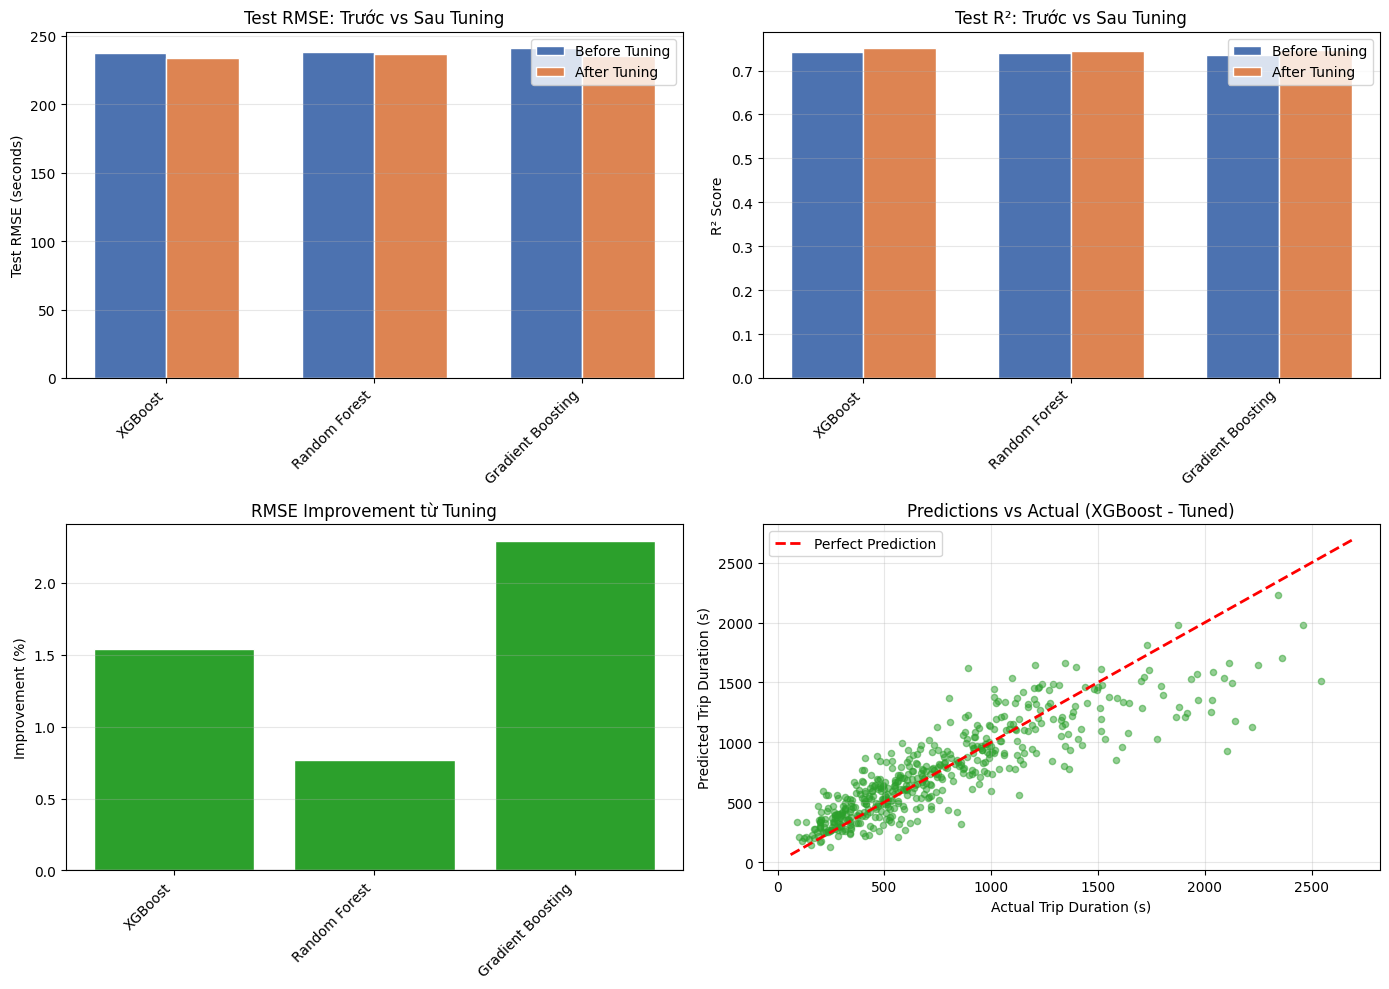

✅ Visualization saved as 'trip_duration_tuning_comparison.png'


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: RMSE Trước và Sau Tuning
models_tuning = comparison_tuning_df['Model']
x = np.arange(len(models_tuning))
width = 0.35

axes[0, 0].bar(x - width/2, comparison_tuning_df['Before Tuning RMSE'], width, 
               label='Before Tuning', color='#4C72B0', edgecolor='white')
axes[0, 0].bar(x + width/2, comparison_tuning_df['After Tuning RMSE'], width, 
               label='After Tuning', color='#DD8452', edgecolor='white')
axes[0, 0].set_ylabel('Test RMSE (seconds)')
axes[0, 0].set_title('Test RMSE: Trước vs Sau Tuning')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_tuning, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: R² Trước và Sau Tuning
axes[0, 1].bar(x - width/2, comparison_tuning_df['Before R²'], width, 
               label='Before Tuning', color='#4C72B0', edgecolor='white')
axes[0, 1].bar(x + width/2, comparison_tuning_df['After R²'], width, 
               label='After Tuning', color='#DD8452', edgecolor='white')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('Test R²: Trước vs Sau Tuning')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_tuning, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Cải thiện RMSE (%)
colors_improvement = ['#2CA02C' if x > 0 else '#D62728' for x in comparison_tuning_df['RMSE Improvement (%)']]
axes[1, 0].bar(models_tuning, comparison_tuning_df['RMSE Improvement (%)'], color=colors_improvement, edgecolor='white')
axes[1, 0].set_ylabel('Improvement (%)')
axes[1, 0].set_title('RMSE Improvement từ Tuning')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].set_xticklabels(models_tuning, rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Actual vs Predicted cho best tuned model
best_tuned_model = tuned_models[best_tuned_model_name]
y_pred_best_tuned = best_tuned_model['y_pred']

n_sample = min(500, len(y_test))
axes[1, 1].scatter(y_test.iloc[:n_sample], y_pred_best_tuned[:n_sample], 
                   alpha=0.5, s=20, color='#2CA02C')
min_val = min(y_test.min(), y_pred_best_tuned.min())
max_val = max(y_test.max(), y_pred_best_tuned.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Trip Duration (s)')
axes[1, 1].set_ylabel('Predicted Trip Duration (s)')
axes[1, 1].set_title(f'Predictions vs Actual ({best_tuned_model_name} - Tuned)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trip_duration_tuning_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

print("✅ Visualization saved as 'trip_duration_tuning_comparison.png'")


## 11. Visualize Model Performance

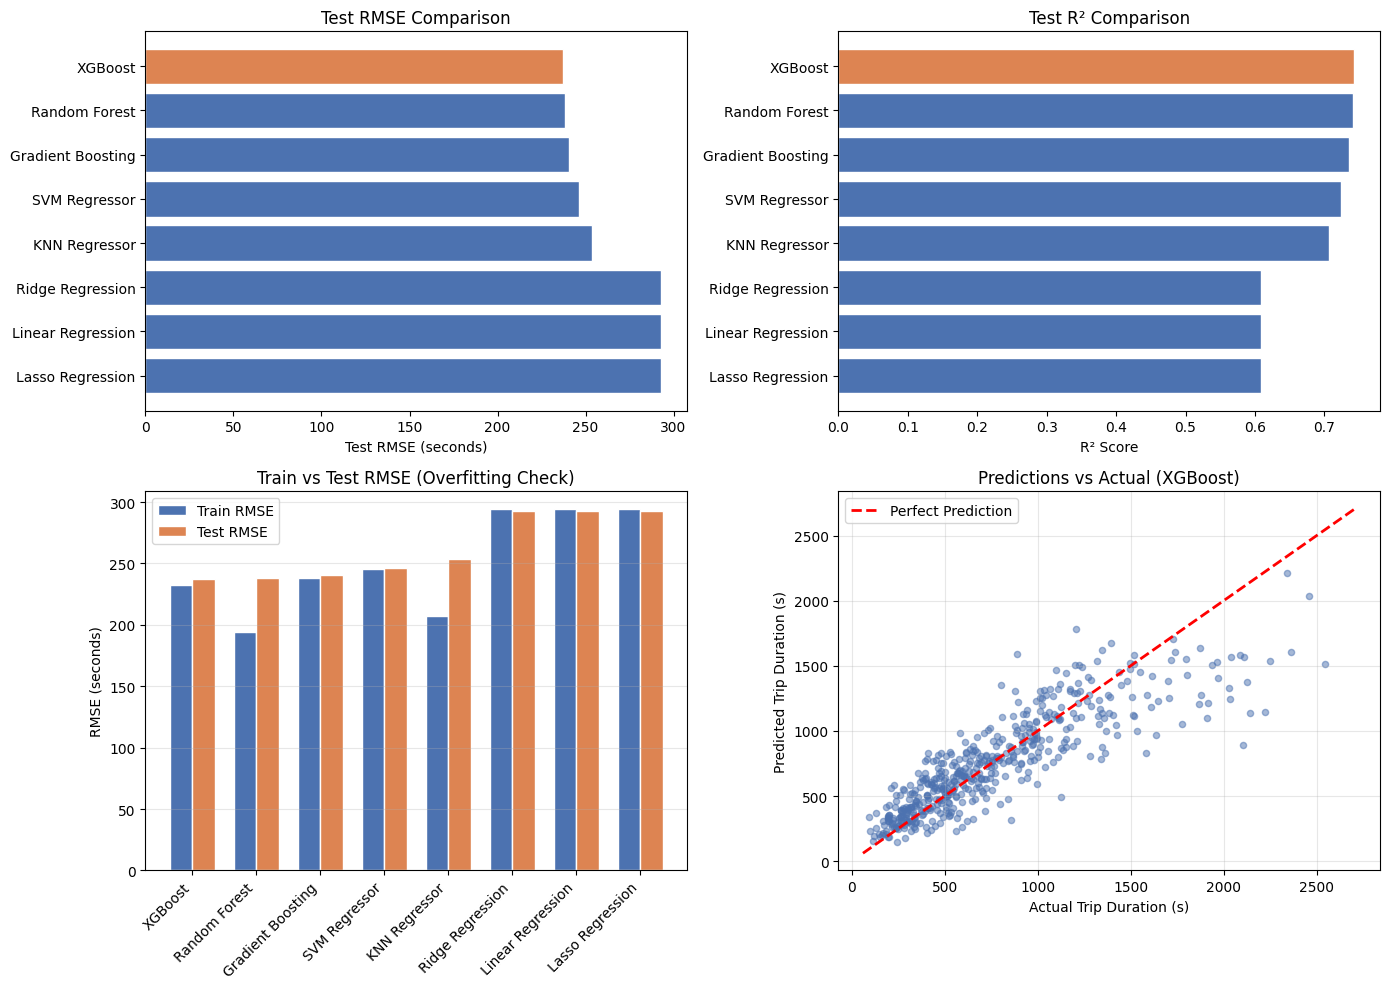

✅ Visualization saved as 'trip_duration_model_comparison.png'


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Test RMSE comparison
comparison_sorted = comparison_df.sort_values('Test RMSE')
colors = ['#DD8452' if m == best_model_name else '#4C72B0' for m in comparison_sorted['Model']]
axes[0, 0].barh(comparison_sorted['Model'], comparison_sorted['Test RMSE'], color=colors, edgecolor='white')
axes[0, 0].set_xlabel('Test RMSE (seconds)')
axes[0, 0].set_title('Test RMSE Comparison')
axes[0, 0].invert_yaxis()

# Plot 2: Test R² comparison
comparison_sorted_r2 = comparison_df.sort_values('Test R²', ascending=False)
colors = ['#DD8452' if m == best_model_name else '#4C72B0' for m in comparison_sorted_r2['Model']]
axes[0, 1].barh(comparison_sorted_r2['Model'], comparison_sorted_r2['Test R²'], color=colors, edgecolor='white')
axes[0, 1].set_xlabel('R² Score')
axes[0, 1].set_title('Test R² Comparison')
axes[0, 1].invert_yaxis()

# Plot 3: Train vs Test RMSE (overfitting check)
models_to_plot = comparison_df['Model']
x = np.arange(len(models_to_plot))
width = 0.35

axes[1, 0].bar(x - width/2, comparison_df['Train RMSE'], width, label='Train RMSE', color='#4C72B0', edgecolor='white')
axes[1, 0].bar(x + width/2, comparison_df['Test RMSE'], width, label='Test RMSE', color='#DD8452', edgecolor='white')
axes[1, 0].set_ylabel('RMSE (seconds)')
axes[1, 0].set_title('Train vs Test RMSE (Overfitting Check)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_to_plot, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Predictions vs Actual (Best Model)
best_model_results = results[best_model_name]
y_pred_best = best_model_results['y_pred']

# Plot first 500 predictions for clarity
n_sample = min(500, len(y_test))
axes[1, 1].scatter(y_test.iloc[:n_sample], y_pred_best[:n_sample], alpha=0.5, s=20, color='#4C72B0')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Trip Duration (s)')
axes[1, 1].set_ylabel('Predicted Trip Duration (s)')
axes[1, 1].set_title(f'Predictions vs Actual ({best_model_name})')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trip_duration_model_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

print("✅ Visualization saved as 'trip_duration_model_comparison.png'")

## 12. Dự đoán Trip Duration cho toàn bộ Dataset

In [16]:
print(f"Dùng mô hình {best_tuned_model_name} (tuned) để dự đoán toàn bộ dataset...")

best_model = tuned_models[best_tuned_model_name]['model']
best_model_needs_scaling = tuned_models[best_tuned_model_name]['scaled']

# Prepare full data
X_full = df[available_features].copy()
if best_model_needs_scaling:
    X_full_scaled = scaler.transform(X_full)
    y_pred_full = best_model.predict(X_full_scaled)
else:
    y_pred_full = best_model.predict(X_full)

# Thêm cột prediction vào dataframe
df['predicted_trip_duration'] = y_pred_full

print(f"✅ Dự đoán hoàn tất!")
print(f"\nPredicted trip_duration statistics:")
print(df['predicted_trip_duration'].describe())
print(f"\nActual vs Predicted:")
print(f"  Actual mean: {df['trip_duration'].mean():.2f}s")
print(f"  Predicted mean: {df['predicted_trip_duration'].mean():.2f}s")
print(f"\nSample predictions:")
sample_df = df[['trip_distance', 'rush_hour', 'cluster_id', 'trip_duration', 'predicted_trip_duration']].head(10)
print(sample_df)


Dùng mô hình XGBoost (tuned) để dự đoán toàn bộ dataset...
✅ Dự đoán hoàn tất!

Predicted trip_duration statistics:
count    199925.000000
mean        743.741882
std         408.476257
min          53.361370
25%         429.184082
50%         657.906738
75%         975.321594
max        2688.450439
Name: predicted_trip_duration, dtype: float64

Actual vs Predicted:
  Actual mean: 743.82s
  Predicted mean: 743.74s

Sample predictions:
     trip_distance  rush_hour  cluster_id  trip_duration  \
62            1.10          0           0          209.0   
79            7.06          0          -1          914.0   
88            3.25          0           0          749.0   
93            2.85          0          -1          770.0   
105           2.99          0           0          657.0   
117           1.47          0           0          306.0   
122           1.20          0           0          571.0   
134           0.70          0           0          226.0   
170           1.07    

## 13. Lưu kết quả

In [17]:
# Lưu dataframe với predictions
output_path = '../data/raw/taxi_with_predictions.csv'

# Chọn columns để lưu
save_cols = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'trip_distance', 'passenger_count',
    'trip_duration', 'predicted_trip_duration',
    'cluster_id', 'rush_hour'
]

save_cols = [c for c in save_cols if c in df.columns]
df_export = df[save_cols].copy()

df_export.to_csv(output_path, index=False)
print(f"✅ Kết quả lưu vào: {output_path}")
print(f"   Số dòng: {len(df_export)}")
print(f"   Số cột: {len(df_export.columns)}")

# Lưu model evaluation report
report_path = '../data/raw/trip_duration_model_report.txt'
with open(report_path, 'w') as f:
    f.write("=" * 120 + "\n")
    f.write("TRIP DURATION PREDICTION - MODEL EVALUATION REPORT (WITH HYPERPARAMETER TUNING)\n")
    f.write("=" * 120 + "\n\n")
    
    f.write("🏆 BEST MODEL AFTER TUNING\n")
    f.write("-" * 120 + "\n")
    f.write(f"Model Name: {best_tuned_model_name}\n")
    f.write(f"Test RMSE: {best_tuned_rmse:.2f} seconds\n")
    f.write(f"Test MAE: {tuned_models[best_tuned_model_name]['test_mae']:.2f} seconds\n")
    f.write(f"Test R²: {best_tuned_r2:.4f}\n")
    f.write(f"Test MAPE: {tuned_models[best_tuned_model_name]['test_mape']:.2%}\n")
    f.write(f"RMSE Improvement: {improvement:.2f}%\n\n")
    
    f.write("Best Hyperparameters:\n")
    for param, value in tuned_models[best_tuned_model_name]['best_params'].items():
        f.write(f"  - {param}: {value}\n")
    f.write("\n")
    
    f.write("=" * 120 + "\n")
    f.write("ALL MODELS COMPARISON (BEFORE AND AFTER TUNING)\n")
    f.write("-" * 120 + "\n")
    f.write(comparison_tuning_df.to_string(index=False))
    f.write("\n\n")
    
    f.write("=" * 120 + "\n")
    f.write("INITIAL MODELS EVALUATION\n")
    f.write("-" * 120 + "\n")
    f.write(comparison_df.to_string(index=False))
    f.write("\n")

print(f"✅ Report lưu vào: {report_path}")


✅ Kết quả lưu vào: ../data/raw/taxi_with_predictions.csv
   Số dòng: 199925
   Số cột: 12
✅ Report lưu vào: ../data/raw/trip_duration_model_report.txt


## 14. Tóm tắt kết quả

In [18]:
print("\n" + "="*100)
print("📋 TÓM TẮT KẾT QUẢ - DỰ ĐOÁN TRIP DURATION (VỚI HYPERPARAMETER TUNING)")
print("="*100)

print(f"\n✅ BƯỚC 1: DATA PREPARATION")
print(f"   - Loaded data: {len(df)} records")
print(f"   - Cluster ID: {df['cluster_id'].nunique()} clusters (từ bài toán cluster)")
print(f"   - Rush hour label (từ bài toán rush_hour)")
print(f"   - Target variable (trip_duration): {df['trip_duration'].min():.0f}s - {df['trip_duration'].max():.0f}s")

print(f"\n✅ BƯỚC 2: FEATURE ENGINEERING")
print(f"   - Total features used: {len(available_features)}")
print(f"   - Features: {', '.join(available_features)}")

print(f"\n✅ BƯỚC 3: INITIAL MODEL TRAINING & COMPARISON")
print(f"   - Total models trained: {len(models)}")
print(f"   - Train/Test split: 80/20")
print(f"   - Cross-validation: 5-Fold")
print(f"   - Top 3 models selected for tuning:")
for i, model in enumerate(top_3_models, 1):
    rmse = comparison_df[comparison_df['Model'] == model]['Test RMSE'].values[0]
    print(f"      {i}. {model}: RMSE={rmse:.2f}s")

print(f"\n✅ BƯỚC 4: HYPERPARAMETER TUNING")
print(f"   - GridSearchCV với 5-fold cross-validation")
print(f"   - Tuned 3 best models với custom parameter grids")
print(f"   - Kết quả tuning:")
for model_name in top_3_models:
    if model_name in tuned_models:
        before_rmse = comparison_df[comparison_df['Model'] == model_name]['Test RMSE'].values[0]
        after_rmse = tuned_models[model_name]['test_rmse']
        improvement = ((before_rmse - after_rmse) / before_rmse * 100)
        print(f"      {model_name}:")
        print(f"        - Before: {before_rmse:.2f}s → After: {after_rmse:.2f}s (Improvement: {improvement:.2f}%)")

print(f"\n✅ BƯỚC 5: MODEL SELECTION (AFTER TUNING)")
print(f"   🏆 BEST MODEL: {best_tuned_model_name}")
print(f"      - Test RMSE: {best_tuned_rmse:.2f} seconds")
print(f"      - Test MAE: {tuned_models[best_tuned_model_name]['test_mae']:.2f} seconds")
print(f"      - Test R²: {best_tuned_r2:.4f}")
print(f"      - Test MAPE: {tuned_models[best_tuned_model_name]['test_mape']:.2%}")
print(f"      - Total RMSE Improvement: {improvement:.2f}%")

print(f"\n✅ BƯỚC 6: FINAL PREDICTIONS")
print(f"   - Predicted trip_duration for all {len(df)} records")
print(f"   - Prediction range: {df['predicted_trip_duration'].min():.0f}s - {df['predicted_trip_duration'].max():.0f}s")
print(f"   - Mean prediction: {df['predicted_trip_duration'].mean():.2f}s")

print(f"\n✅ BƯỚC 7: OUTPUT FILES")
print(f"   - Data with predictions: {output_path}")
print(f"   - Model evaluation report: {report_path}")
print(f"   - Visualizations:")
print(f"     * trip_duration_model_comparison.png")
print(f"     * trip_duration_tuning_comparison.png")

print("\n" + "="*100)
print("✅ Hoàn tất bài toán dự đoán Trip Duration với Hyperparameter Tuning!")
print("="*100)



📋 TÓM TẮT KẾT QUẢ - DỰ ĐOÁN TRIP DURATION (VỚI HYPERPARAMETER TUNING)

✅ BƯỚC 1: DATA PREPARATION
   - Loaded data: 199925 records
   - Cluster ID: 6 clusters (từ bài toán cluster)
   - Rush hour label (từ bài toán rush_hour)
   - Target variable (trip_duration): 61s - 2655s

✅ BƯỚC 2: FEATURE ENGINEERING
   - Total features used: 8
   - Features: trip_distance, pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude, cluster_id, rush_hour, passenger_count

✅ BƯỚC 3: INITIAL MODEL TRAINING & COMPARISON
   - Total models trained: 8
   - Train/Test split: 80/20
   - Cross-validation: 5-Fold
   - Top 3 models selected for tuning:
      1. XGBoost: RMSE=237.43s
      2. Random Forest: RMSE=238.38s
      3. Gradient Boosting: RMSE=240.89s

✅ BƯỚC 4: HYPERPARAMETER TUNING
   - GridSearchCV với 5-fold cross-validation
   - Tuned 3 best models với custom parameter grids
   - Kết quả tuning:
      XGBoost:
        - Before: 237.43s → After: 233.78s (Improvement: 1.54%)
      Ran